In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as snsy
from sklearn.preprocessing import MinMaxScaler
from surprise import SVD, Dataset, Reader
from surprise.model_selection import train_test_split
from surprise import accuracy

--- Eksplorasi Ukuran Data ---
Jumlah Baris Data Awal : 114000
Jumlah Kolom Data Awal : 22

--- Analisis Kualitas Data (Missing Values) ---
artists       1
album_name    1
track_name    1
dtype: int64

--- Analisis Data Duplikat ---
Jumlah duplikasi berdasarkan track_id: 24259

--- Menampilkan Visualisasi Grafik EDA ---


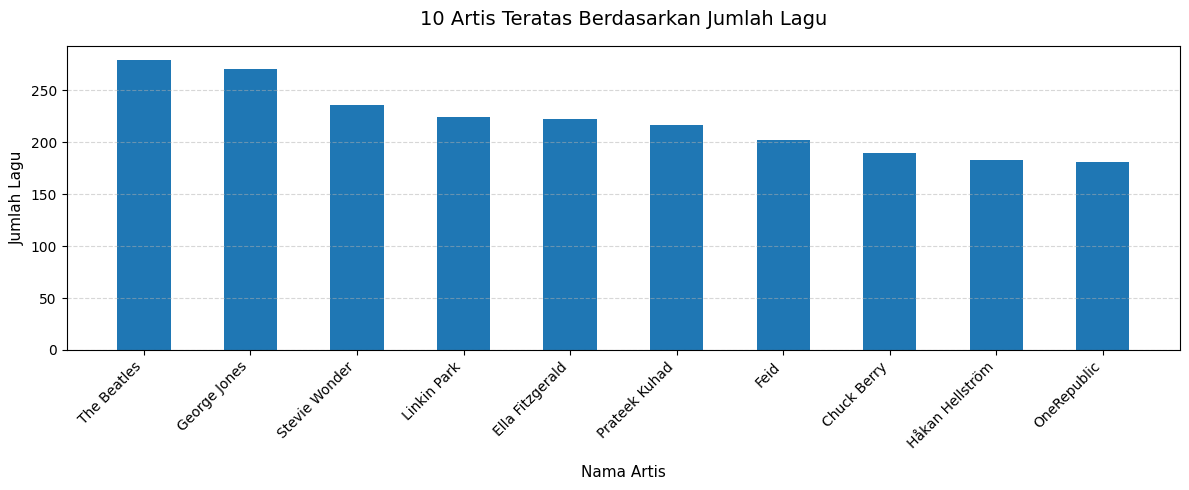

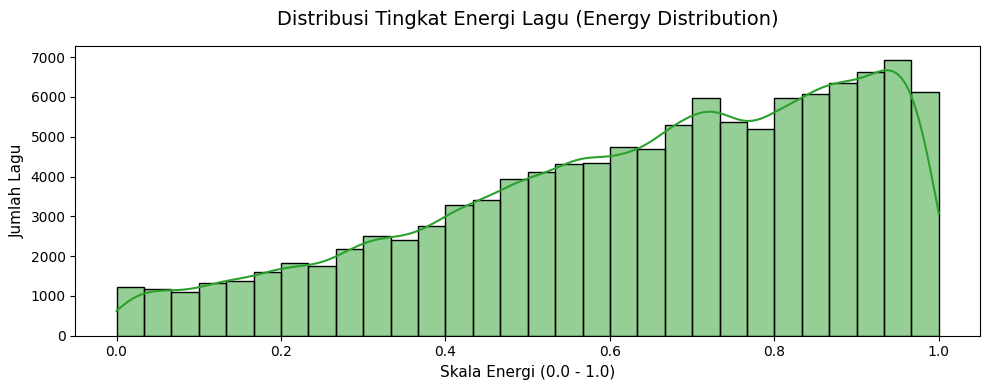

In [14]:
# CRISP-DM TAHAP 2: DATA UNDERSTANDING

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Membaca dataset Spotify dari Kaggle
df_raw = pd.read_csv('spotify-tracks-dataset.csv')

print("--- Eksplorasi Ukuran Data ---")
print(f"Jumlah Baris Data Awal : {df_raw.shape[0]}")
print(f"Jumlah Kolom Data Awal : {df_raw.shape[1]}")

print("\n--- Analisis Kualitas Data (Missing Values) ---")
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])

print("\n--- Analisis Data Duplikat ---")
print(f"Jumlah duplikasi berdasarkan track_id: {df_raw.duplicated(subset=['track_id']).sum()}")

# EXPLORATORY DATA ANALYSIS (EDA) - VISUALISASI DATA
print("\n--- Menampilkan Visualisasi Grafik EDA ---")

# Grafik A: 10 Artis Teratas Berdasarkan Jumlah Lagu
top_artists = df_raw['artists'].value_counts().head(10)
plt.figure(figsize=(12, 5))
plt.bar(top_artists.index, top_artists.values, color='#1f77b4', width=0.5)
plt.title('10 Artis Teratas Berdasarkan Jumlah Lagu', fontsize=14, pad=15)
plt.xlabel('Nama Artis', fontsize=11, labelpad=10)
plt.ylabel('Jumlah Lagu', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Grafik B: Distribusi Tingkat Energi Musik
plt.figure(figsize=(10, 4))
sns.histplot(df_raw['energy'], bins=30, kde=True, color='#2ca02c')
plt.title('Distribusi Tingkat Energi Lagu (Energy Distribution)', fontsize=14, pad=15)
plt.xlabel('Skala Energi (0.0 - 1.0)', fontsize=11)
plt.ylabel('Jumlah Lagu', fontsize=11)
plt.tight_layout()
plt.show()

In [15]:
# CRISP-DM TAHAP 3: DATA PREPARATION

from sklearn.preprocessing import MinMaxScaler

# 1. Pembersihan Data Duplikat & Missing Value
df_clean = df_raw.drop_duplicates(subset=['track_id']).copy()
df_clean.dropna(subset=['track_name', 'artists'], inplace=True)

# 2. Mengambil Sampel Acak (Sampling) sebesar 25.000 data agar tidak over-memory (RAM Crash)
df_filtered = df_clean.sample(n=25000, random_state=42).reset_index(drop=True)

# 3. Pembentukan Data Interaksi Pengguna (User-Interaction Tiruan)
np.random.seed(42)
df_filtered['user_id'] = np.random.randint(1000, 5000, size=len(df_filtered))

# Normalisasi Popularitas (0-100) menjadi Skala Rating Interaksi (1-10)
df_filtered['user_rating'] = (df_filtered['popularity'] / 10).round().astype(int)
df_filtered['user_rating'] = df_filtered['user_rating'].replace(0, 1)

# Memfilter data dengan membatasi nilai kelayakan rating minimal 3
df_filtered = df_filtered[df_filtered['user_rating'] >= 3].reset_index(drop=True)

# 4. Transformasi Variabel Kategori Track ID menjadi Indeks Numerik untuk Embedding
df_filtered['track_index'] = df_filtered['track_id'].astype('category').cat.codes

# 5. Feature Scaling untuk Content-Based Filtering
audio_features = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(df_filtered[audio_features])

print("--- Hasil Akhir Tahap Data Preparation ---")
print(f"Jumlah baris lagu siap pakai             : {df_filtered.shape[0]}")
print(f"Dimensi matriks fitur audio hasil scaling: {scaled_features.shape}")

--- Hasil Akhir Tahap Data Preparation ---
Jumlah baris lagu siap pakai             : 15312
Dimensi matriks fitur audio hasil scaling: (15312, 9)


In [16]:
# CRISP-DM TAHAP 4 & 5: MODELING & EVALUATION (METODE 1 & 2)

from sklearn.neighbors import NearestNeighbors
from surprise import SVD, Dataset, Reader
from surprise.model_selection import cross_validate

print("1. EVALUASI & MODELING CONTENT-BASED FILTERING")
# Mengembangkan model K-NN dengan metrik Cosine Similarity
nn_model = NearestNeighbors(metric='cosine', algorithm='brute')
nn_model.fit(scaled_features)

# Fungsi Penarik Top-N Rekomendasi Lagu Serupa
def recommend_songs_nn(track_name, n=5):
    if track_name not in df_filtered['track_name'].values:
        return f"Lagu '{track_name}' tidak ditemukan di dalam subsampel data."

    idx = df_filtered[df_filtered['track_name'] == track_name].index[0]
    distances, indices = nn_model.kneighbors([scaled_features[idx]], n_neighbors=n+1)

    return df_filtered.iloc[indices[0][1:]][['track_name', 'artists', 'album_name']]

# Uji Coba Pengujian Contoh Rekomendasi Musik
sample_target_song = df_filtered['track_name'].iloc[0]
print(f"\nTop-{5} Rekomendasi Berbasis Konten Fitur Audio Untuk Lagu: '{sample_target_song}'")
print(recommend_songs_nn(sample_target_song, n=5))


print("\n 2. EVALUASI & MODELING COLLABORATIVE FILTERING (SVD) ")
# Menyiapkan dataset ke format library Surprise
reader = Reader(rating_scale=(1, 10))
data_surprise = Dataset.load_from_df(df_filtered[["user_id", "track_id", "user_rating"]], reader)

# Validasi performa matriks SVD menggunakan Cross Validation 5-Fold
model_svd = SVD(random_state=42)
print("Menghitung Skor Nilai Eror Menggunakan Metode Evaluasi Cross-Validation...")
cv_results = cross_validate(model_svd, data_surprise, cv=5, measures=['RMSE', 'MAE'], verbose=True)

========== 1. EVALUASI & MODELING CONTENT-BASED FILTERING ==========

Top-5 Rekomendasi Berbasis Konten Fitur Audio Untuk Lagu: 'Kamikadze wróć!'
                                 track_name  \
534                                La Chula   
6281            Settaigalai Virikkum Kaalam   
11086              アリよさらば - Remastered 2022   
3860    Koi Na Koi Chahiye (From "Deewana")   
7607   Cutiepie (From "Ae Dil Hai Mushkil")   

                                     artists  \
534                              Miguel Bosé   
6281                        Gersson Edinbaro   
11086                         Eikichi Yazawa   
3860                            Vinod Rathod   
7607   Pritam;Pardeep Singh Sran;Nakash Aziz   

                                             album_name  
534                                Esencial Miguel Bose  
6281                        Settaigalai Virikkum Kaalam  
11086        the Name Is… (50th Anniversary Remastered)  
3860   Best of Bollywood Singers - Shaan & Vinod R

--- Ringkasan Spesifikasi Lapisan Struktur Jaringan ---


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_id             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ isbn (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 50)     │    250,000 │ user_id[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 50)     │    765,600 │ isbn[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_10          │ (None, 50)        │          0 │ embedding[0][0]   │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_11          │ (None, 50)        │          0 │ embedding_1[0][0] │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 100)       │          0 │ flatten_10[0][0], │
│ (Concatenate)       │                   │            │ flatten_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 128)       │     12,928 │ concatenate_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 64)        │      8,256 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         65 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,036,849 (3.96 MB)

 Trainable params: 1,036,849 (3.96 MB)

 Non-trainable params: 0 (0.00 B)


Memulai Komputasi Proses Training Model Neural Network...
Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 16.7101 - root_mean_squared_error: 4.0878 - val_loss: 5.2643 - val_root_mean_squared_error: 2.2944
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 2.4448 - root_mean_squared_error: 1.5636 - val_loss: 2.1699 - val_root_mean_squared_error: 1.4731
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 1.3589 - root_mean_squared_error: 1.1657 - val_loss: 2.3619 - val_root_mean_squared_error: 1.5368
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.6111 - root_mean_squared_error: 0.7818 - val_loss: 2.3747 - val_root_mean_squared_error: 1.5410
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.4856 - root_mean_squared_error: 0.6969 - val_loss: 2.3211 - val_root_mean_squared_error: 1.5235
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.3866 - root_mean_squared_error: 0.6218 - val_loss: 2.2975 - val_root_mean_squared_error: 1.515

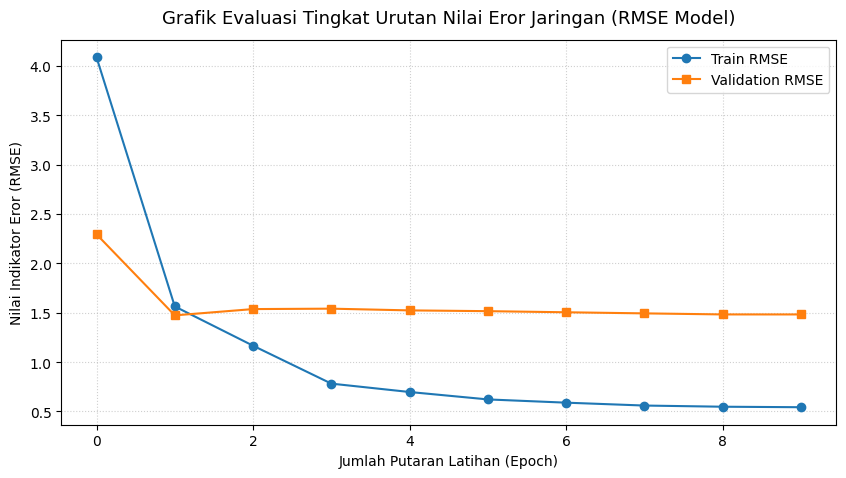

In [22]:
# CRISP-DM TAHAP 4 & 5: MODELING & EVALUATION (METODE 3: DEEP LEARNING)

import tensorflow as tf
import matplotlib.pyplot as plt

# 1. PERBAIKAN UTAMA: Menentukan dimensi dengan nilai indeks maksimum
num_users = df_filtered['user_id'].max() + 1
num_tracks = df_filtered['track_index'].max() + 1

# 2. Rekonstruksi Jaringan Saraf Tiruan
user_input = tf.keras.layers.Input(shape=(1,), name='user_id')
track_input = tf.keras.layers.Input(shape=(1,), name='isbn')

user_embed = tf.keras.layers.Embedding(output_dim=50, input_dim=num_users, name='embedding')(user_input)
track_embed = tf.keras.layers.Embedding(output_dim=50, input_dim=num_tracks, name='embedding_1')(track_input)

user_flat = tf.keras.layers.Flatten()(user_embed)
track_flat = tf.keras.layers.Flatten()(track_embed)

concat = tf.keras.layers.Concatenate()([user_flat, track_flat])

dense1 = tf.keras.layers.Dense(128, activation='relu')(concat)
dense2 = tf.keras.layers.Dense(64, activation='relu')(dense1)
dropout = tf.keras.layers.Dropout(0.2)(dense2)
output = tf.keras.layers.Dense(1, name='dense_2')(dropout)

model_nn = tf.keras.models.Model(inputs=[user_input, track_input], outputs=output)
model_nn.compile(optimizer='adam', loss='mse', metrics=[tf.keras.metrics.RootMeanSquaredError()])

print("--- Ringkasan Spesifikasi Lapisan Struktur Jaringan ---")
model_nn.summary()

# 3. Proses Training Data Neural Network
print("\nMemulai Komputasi Proses Training Model Neural Network...")
X_user_data = df_filtered['user_id'].values
X_track_data = df_filtered['track_index'].values
Y_rating_target = df_filtered['user_rating'].values

# Pemetaan input menggunakan format dictionary terpadu
history = model_nn.fit(
    x={'user_id': X_user_data, 'isbn': X_track_data},
    y=Y_rating_target,
    epochs=10,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)

# 4. VISUALISASI EVALUASI GRAFIK NILAI ERROR
plt.figure(figsize=(10, 5))
plt.plot(history.history['root_mean_squared_error'], label='Train RMSE', color='#1f77b4', marker='o')
plt.plot(history.history['val_root_mean_squared_error'], label='Validation RMSE', color='#ff7f0e', marker='s')
plt.title('Grafik Evaluasi Tingkat Urutan Nilai Eror Jaringan (RMSE Model)', fontsize=13, pad=12)
plt.xlabel('Jumlah Putaran Latihan (Epoch)')
plt.ylabel('Nilai Indikator Eror (RMSE)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [23]:
# CRISP-DM TAHAP 6: DEPLOYMENT

# Menyimpan dataset yang sudah bersih menjadi berkas baru untuk backend aplikasi deployment
df_filtered.to_csv('spotify_processed_data.csv', index=False)

print("Tahap 6: Deployment Berhasil Disiapkan.")
print("Berkas 'spotify_processed_data.csv' siap diunduh dan diintegrasikan ke repositori GitHub/Aplikasi Streamlit!")

Tahap 6: Deployment Berhasil Disiapkan.
Berkas 'spotify_processed_data.csv' siap diunduh dan diintegrasikan ke repositori GitHub/Aplikasi Streamlit!
